In [1]:
import json
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob

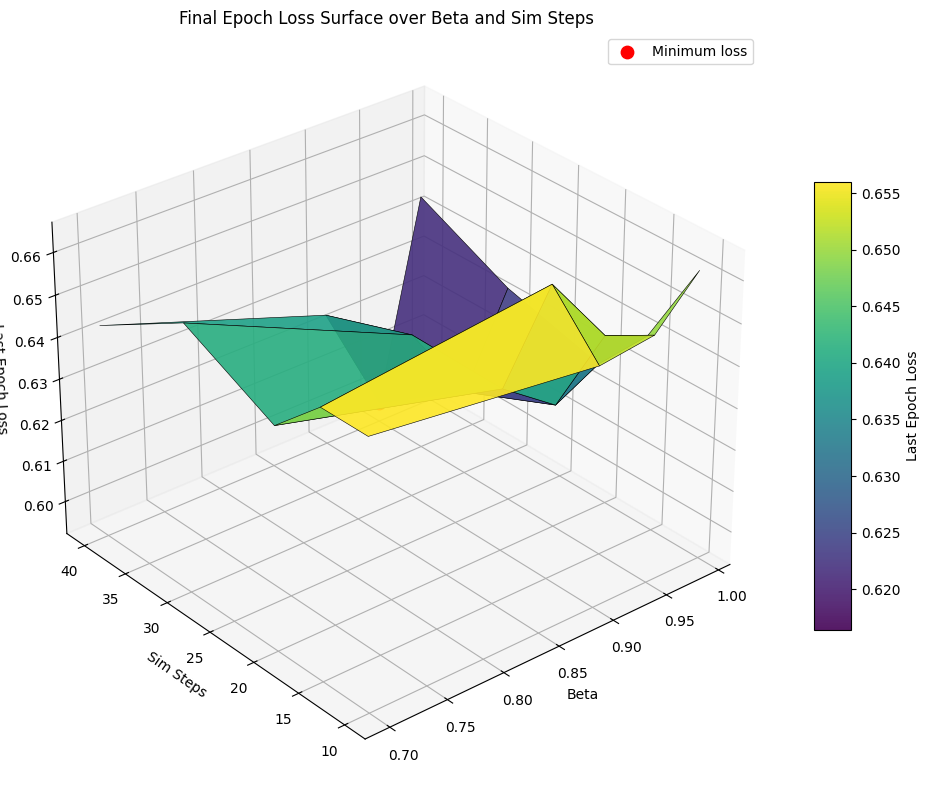

=== Best Parameter Combination (Minimum Last-Epoch Loss) ===
Beta: 0.95
Sim Steps: 40
Last Epoch Loss: 0.596758
File: hypr_2026-04-26_16-49-15_e-10_s-40_spatial.json


In [2]:
# Build a 3D surface of final-epoch loss over (beta, sim_steps)
import numpy as np

files = sorted(glob('../output_results/E2/hypr_*.json'))
if not files:
    raise FileNotFoundError('No matching files found in ../output_results/E2')

records = []  # (beta, sim_steps, last_epoch_loss, file_name)
for file in files:
    with open(file, 'r', encoding='utf-8') as f:
        data = json.load(f)

    training_config = data.get('training_config', {})
    results = data.get('results', {})

    beta_raw = training_config.get('beta')
    sim_steps_raw = training_config.get('sim_steps')
    epoch_losses = results.get('epoch_train_loss', [])

    if beta_raw is None or sim_steps_raw is None or not epoch_losses:
        continue

    beta = float(beta_raw)
    sim_steps = float(sim_steps_raw)
    last_epoch_loss = float(epoch_losses[-1])
    records.append((beta, sim_steps, last_epoch_loss, Path(file).name))

if not records:
    raise ValueError('No valid records found with beta, sim_steps, and epoch_train_loss.')

betas = sorted({r[0] for r in records})
sim_steps_vals = sorted({r[1] for r in records})

# Create a rectangular grid for surface plotting.
X, Y = np.meshgrid(betas, sim_steps_vals)
Z = np.full_like(X, np.nan, dtype=float)

for beta, sim_steps, loss, _ in records:
    x_idx = betas.index(beta)
    y_idx = sim_steps_vals.index(sim_steps)
    Z[y_idx, x_idx] = loss

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')

surface = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='k', linewidth=0.4, alpha=0.9)
fig.colorbar(surface, ax=ax, shrink=0.6, aspect=12, label='Last Epoch Loss')

# Mark the global minimum loss point (best parameters).
best_beta, best_sim_steps, best_loss, best_file = min(records, key=lambda x: x[2])
ax.scatter(best_beta, best_sim_steps, best_loss, color='red', s=80, label='Minimum loss')
ax.legend()

ax.set_title('Final Epoch Loss Surface over Beta and Sim Steps')
ax.set_xlabel('Beta')
ax.set_ylabel('Sim Steps')
ax.set_zlabel('Last Epoch Loss')
ax.view_init(elev=30, azim=-130)
plt.tight_layout()
plt.show()

print('=== Best Parameter Combination (Minimum Last-Epoch Loss) ===')
print(f'Beta: {best_beta}')
print(f'Sim Steps: {best_sim_steps:g}')
print(f'Last Epoch Loss: {best_loss:.6f}')
print(f'File: {best_file}')